<a href="https://colab.research.google.com/github/Fachreza28/pba-task-1a-individual/blob/main/Week2_APPSREV_mybca_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Assuming the uploaded file is a CSV
  try:
    df_mybcarev = pd.read_csv(io.BytesIO(uploaded[fn]))
    print("Successfully loaded CSV into df_mybcarev")
  except pd.errors.ParserError:
      print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
      df_mybcarev = pd.DataFrame() # Create an empty DataFrame if parsing fails
  except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df_mybcarev = pd.DataFrame()


Saving df_mybcarev_before_stopwords_sentiment_rating.csv to df_mybcarev_before_stopwords_sentiment_rating.csv
User uploaded file "df_mybcarev_before_stopwords_sentiment_rating.csv" with length 230984494 bytes
Successfully loaded CSV into df_mybcarev


In [ ]:
df_mybcarev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount,sentiment_rating
0,dc58de2a-b0f2-4b4c-84d3-fcd64b24e0df,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,4.7.9,2026-03-29 12:58:17,Thank you for the review. Hopefully the BCA mo...,2026-03-29 14:04:27,4.7.9,0.5,0.5,1,0,0,Positive
1,122b9d3b-f122-48b3-b1c0-54e54cf52923,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"susa amat buat qris di cek internet bagus, dic...",1,0,4.7.9,2026-03-29 12:30:18,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-03-29 12:48:54,4.7.9,0.0,0.0,21,0,3,Negative
2,d6bcfc0c-e9d0-4115-97f6-c110a9d5ba41,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ter indah tiasa 2 nya....,5,0,4.7.9,2026-03-29 12:05:14,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 12:48:28,4.7.9,0.0,0.0,5,0,4,Positive
3,d795e116-5f04-47d8-866c-5592036801d4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dengan bca mobile transaksi lebih mudah ga pak...,5,0,4.7.9,2026-03-29 11:39:58,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:44:30,4.7.9,0.0,0.0,26,0,0,Positive
4,a210fcc0-b3ed-4da5-bd31-287327b008bb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,5,0,4.7.9,2026-03-29 11:39:20,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:42:58,4.7.9,0.0,0.0,6,0,0,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512151,b8e9396f-a75b-442b-9099-2370c2832256,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,NaN,2012-11-29 03:01:32,NaN,NaN,NaN,0.0,0.0,2,0,0,Positive
512152,b1be7ea4-9674-478b-b205-a0f9bf8d8984,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,oke,5,0,NaN,2012-11-28 16:31:41,NaN,NaN,NaN,0.0,0.0,1,0,0,Positive
512153,b5f2d3c4-1cca-4e39-91b9-9435963002ca,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,NaN,2012-11-28 16:18:29,NaN,NaN,NaN,0.7,0.6,1,0,0,Positive
512154,bcc9d186-e54b-42ad-8e7c-88303e71378a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good mempermudah saya utk brtransaksi dmnapun ...,4,0,NaN,2012-11-25 02:49:55,NaN,NaN,NaN,0.7,0.6,9,0,0,Positive


In [ ]:
df_mybcarev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512156 entries, 0 to 512155
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   reviewId              512156 non-null  object 
 1   userName              512156 non-null  object 
 2   userImage             512156 non-null  object 
 3   content               512032 non-null  object 
 4   score                 512156 non-null  int64  
 5   thumbsUpCount         512156 non-null  int64  
 6   reviewCreatedVersion  405729 non-null  object 
 7   at                    512156 non-null  object 
 8   replyContent          479277 non-null  object 
 9   repliedAt             479277 non-null  object 
 10  appVersion            405729 non-null  object 
 11  sentiment_polarity    512156 non-null  float64
 12  sentiment_subjective  512156 non-null  float64
 13  wordCount             512156 non-null  int64  
 14  uppercaseCharCount    512156 non-null  int64  
 15  

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download Indonesian stopwords if not available
nltk.download('stopwords')
indonesian_stopwords = set(stopwords.words('indonesian'))

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_mybcarev[text_column].dropna().astype(str))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_mybcarev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,ok,5,0,4.7.9,2026-03-29 12:58:17,Thank you for the review. Hopefully the BCA mo...,2026-03-29 14:04:27
1,"susa amat buat qris di cek internet bagus, dic...",1,0,4.7.9,2026-03-29 12:30:18,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-03-29 12:48:54
2,ter indah tiasa 2 nya....,5,0,4.7.9,2026-03-29 12:05:14,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 12:48:28
3,dengan bca mobile transaksi lebih mudah ga pak...,5,0,4.7.9,2026-03-29 11:39:58,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:44:30
4,bca mobile memang luar biasa ok🙏🙏👍🤣🤣,5,0,4.7.9,2026-03-29 11:39:20,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-29 11:42:58
...,...,...,...,...,...,...,...
512151,sangat membantu,5,0,NaN,2012-11-29 03:01:32,NaN,NaN
512152,oke,5,0,NaN,2012-11-28 16:31:41,NaN,NaN
512153,good,5,0,NaN,2012-11-28 16:18:29,NaN,NaN
512154,good mempermudah saya utk brtransaksi dmnapun ...,4,0,NaN,2012-11-25 02:49:55,NaN,NaN


##Stopwords Removal
Indonesian Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
print(len(indonesian_stopwords))

758


In [ ]:
indonesian_stopwords

['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

,Word,Frequency
0,bca,74886
1,membantu,43522
2,bagus,40539
3,ok,33870
4,nya,32840
...,...,...
95,koneksi,4604
96,bgt,4592
97,g,4572
98,memuaskan,4558


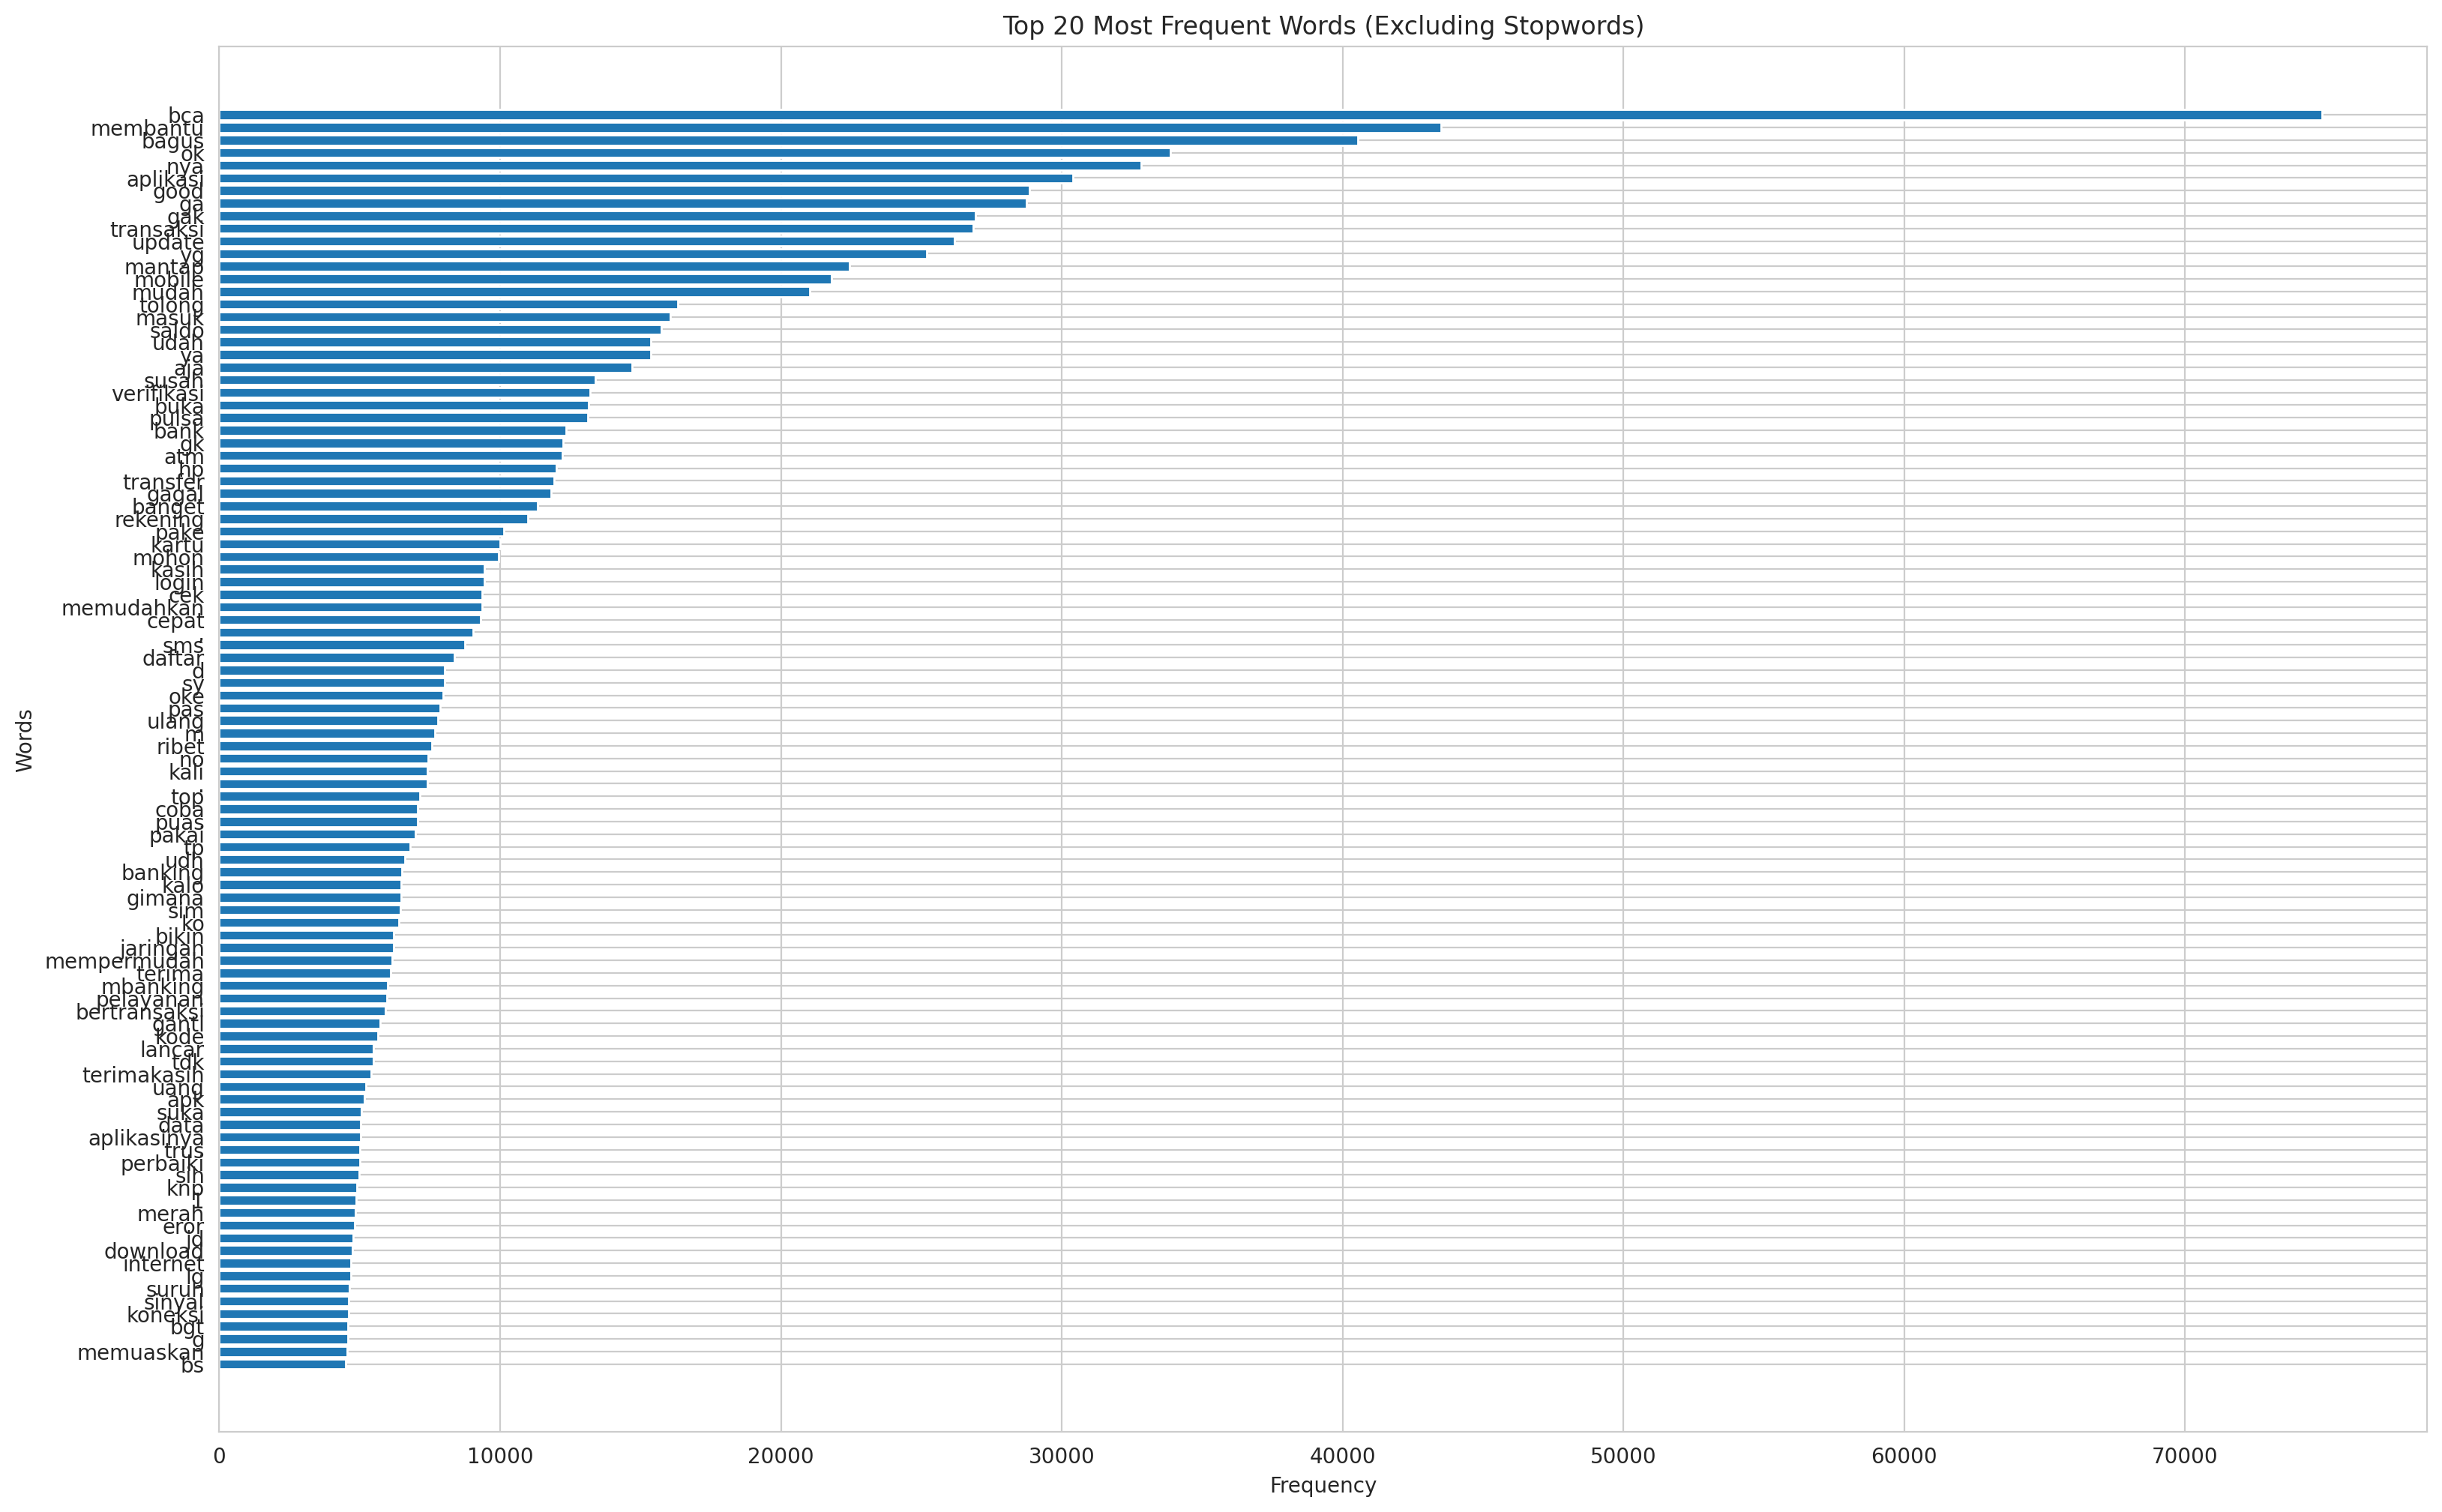

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_mybcarev[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [ ]:
common_words

[('bca', 74886),
 ('membantu', 43522),
 ('bagus', 40539),
 ('ok', 33870),
 ('nya', 32840),
 ('aplikasi', 30408),
 ('good', 28864),
 ('ga', 28731),
 ('gak', 26923),
 ('transaksi', 26855),
 ('update', 26191),
 ('yg', 25185),
 ('mantap', 22435),
 ('mobile', 21805),
 ('mudah', 21037),
 ('tolong', 16336),
 ('masuk', 16053),
 ('saldo', 15728),
 ('udah', 15361),
 ('ya', 15359),
 ('aja', 14694),
 ('susah', 13398),
 ('verifikasi', 13197),
 ('buka', 13157),
 ('pulsa', 13126),
 ('bank', 12346),
 ('gk', 12233),
 ('atm', 12213),
 ('hp', 12005),
 ('transfer', 11922),
 ('gagal', 11823),
 ('banget', 11326),
 ('rekening', 10985),
 ('pake', 10126),
 ('kartu', 10006),
 ('mohon', 9950),
 ('kasih', 9440),
 ('login', 9438),
 ('cek', 9367),
 ('memudahkan', 9348),
 ('cepat', 9319),
 (',', 9040),
 ('sms', 8738),
 ('daftar', 8363),
 ('d', 8023),
 ('sy', 8014),
 ('oke', 7977),
 ('pas', 7853),
 ('ulang', 7785),
 ('m', 7668),
 ('ribet', 7579),
 ('no', 7439),
 ('kali', 7418),
 ('.', 7403),
 ('top', 7149),
 ('coba',

Homework: WEEK 3/ 11 maret 2026 (TUGAS 2)

Bisa menambahkan, list kata dari most frequent words, kata2 yg tidak memiliki arti penting (eg ga (no-2), gak-no4) ke list indonesian_stopwords
